In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Student Performance and Behaviour.csv")

df = df.sample(15000, random_state=40)

display(df.head())
display(df.info())
display(df.describe())
display(df.columns)

,Student_ID,Semester_ID,Age,Gender,Region_Type,Family_Size,Major_Subject,University_Name,Home_City,Parent_Education,...,Attendance_Rate,Library_Visits_Per_Month,Extracurricular_Hours,Sleep_Hours,Social_Media_Usage_Hours,Stress_Level,Motivation_Score,Self_Efficacy_Score,Midterm_Mark,Final_Exam_Score
49877,49878,6,29,Male,Urban,2,Psychology,Ain Shams University,Giza,Diploma,...,95.5,2,9.6,7.8,0.3,8.0,3.5,4.43,53.5,43.4
137820,137821,8,28,Male,Urban,3,Economics,Mansoura University,Sohag,Bachelor,...,93.2,8,8.3,5.4,1.0,8.6,3.6,4.65,45.1,64.1
51193,51194,6,27,Male,Urban,4,Political Science,Assiut University,Rosetta,Primary,...,96.1,10,0.5,5.9,0.2,4.0,4.1,1.28,39.7,51.6
211197,211198,5,22,Female,Rural,6,Business Administration,Sohag University,Mansoura,Bachelor,...,84.0,2,13.6,8.0,2.4,5.4,10.0,8.73,54.8,64.0
87638,87639,3,17,Female,Urban,7,Physics,South Valley University,Girga,Diploma,...,83.5,9,0.5,7.1,4.3,4.1,6.2,3.64,39.9,55.9


<class 'pandas.DataFrame'>
Index: 15000 entries, 49877 to 408403
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Student_ID                15000 non-null  int64  
 1   Semester_ID               15000 non-null  int64  
 2   Age                       15000 non-null  int64  
 3   Gender                    15000 non-null  str    
 4   Region_Type               15000 non-null  str    
 5   Family_Size               15000 non-null  int64  
 6   Major_Subject             15000 non-null  str    
 7   University_Name           15000 non-null  str    
 8   Home_City                 15000 non-null  str    
 9   Parent_Education          15000 non-null  str    
 10  Family_Income_Level       15000 non-null  str    
 11  Internet_Quality          15000 non-null  float64
 12  Study_Space_Quality       15000 non-null  float64
 13  Previous_GPA              15000 non-null  float64
 14  Number_of_Failed_

None

,Student_ID,Semester_ID,Age,Family_Size,Internet_Quality,Study_Space_Quality,Previous_GPA,Number_of_Failed_Courses,Total_Credits_Earned,Weekly_Study_Hours,Attendance_Rate,Library_Visits_Per_Month,Extracurricular_Hours,Sleep_Hours,Social_Media_Usage_Hours,Stress_Level,Motivation_Score,Self_Efficacy_Score,Midterm_Mark,Final_Exam_Score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,249592.179533,4.494333,23.499133,4.997600,6.590927,6.443060,2.789425,1.323933,67.296333,18.212667,79.581380,9.235400,3.980800,6.783747,2.935280,5.516193,5.956067,4.530577,53.701907,57.422513
std,143444.122923,2.291008,4.036403,2.011135,2.176790,2.072686,0.676610,1.467905,35.642252,7.926845,13.228765,3.724851,3.972908,1.198264,2.778097,1.995171,1.946445,1.488548,10.349942,11.300473
min,39.000000,1.000000,17.000000,2.000000,1.000000,1.000000,0.030000,0.000000,12.000000,2.000000,0.100000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,12.000000,0.400000
25%,125372.500000,2.000000,20.000000,3.000000,5.100000,5.000000,2.340000,0.000000,36.000000,12.800000,72.600000,7.000000,1.200000,6.000000,0.800000,4.100000,4.600000,3.510000,46.800000,50.300000
50%,250435.500000,5.000000,24.000000,5.000000,6.700000,6.500000,2.800000,1.000000,65.000000,18.100000,81.800000,9.000000,2.800000,6.800000,2.100000,5.500000,6.000000,4.540000,53.300000,57.500000
75%,373157.750000,7.000000,27.000000,7.000000,8.225000,8.000000,3.280000,2.000000,96.000000,23.500000,89.300000,12.000000,5.500000,7.600000,4.100000,6.900000,7.300000,5.530000,60.500000,64.600000
max,499956.000000,8.000000,30.000000,8.000000,10.000000,10.000000,4.000000,10.000000,144.000000,40.000000,99.900000,24.000000,30.000000,11.000000,12.000000,10.000000,10.000000,10.000000,99.500000,100.000000


Index(['Student_ID', 'Semester_ID', 'Age', 'Gender', 'Region_Type',
       'Family_Size', 'Major_Subject', 'University_Name', 'Home_City',
       'Parent_Education', 'Family_Income_Level', 'Internet_Quality',
       'Study_Space_Quality', 'Previous_GPA', 'Number_of_Failed_Courses',
       'Total_Credits_Earned', 'Weekly_Study_Hours', 'Attendance_Rate',
       'Library_Visits_Per_Month', 'Extracurricular_Hours', 'Sleep_Hours',
       'Social_Media_Usage_Hours', 'Stress_Level', 'Motivation_Score',
       'Self_Efficacy_Score', 'Midterm_Mark', 'Final_Exam_Score'],
      dtype='str')

In [3]:
target = "Final_Exam_Score"   

X = df.drop(target, axis=1)
y = df[target]

num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=40
)

In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=40),
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        random_state=40,
        n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [6]:
results = []
predictions = {}

for name, regressor in models.items():
    model = Pipeline([
        ("preprocess", preprocess),
        ("regressor", regressor)
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    predictions[name] = pred
    
    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    })

results_df = pd.DataFrame(results)
display(results_df)

,Model,MAE,MSE,R2
0,Linear Regression,5.400487,52.848739,0.579787
1,Ridge,5.400418,52.846424,0.579805
2,Lasso,5.781309,58.530706,0.534608
3,Decision Tree,6.431867,66.773640,0.469067
4,Random Forest,4.610477,34.745361,0.723731
5,KNN,5.638953,54.411215,0.567363


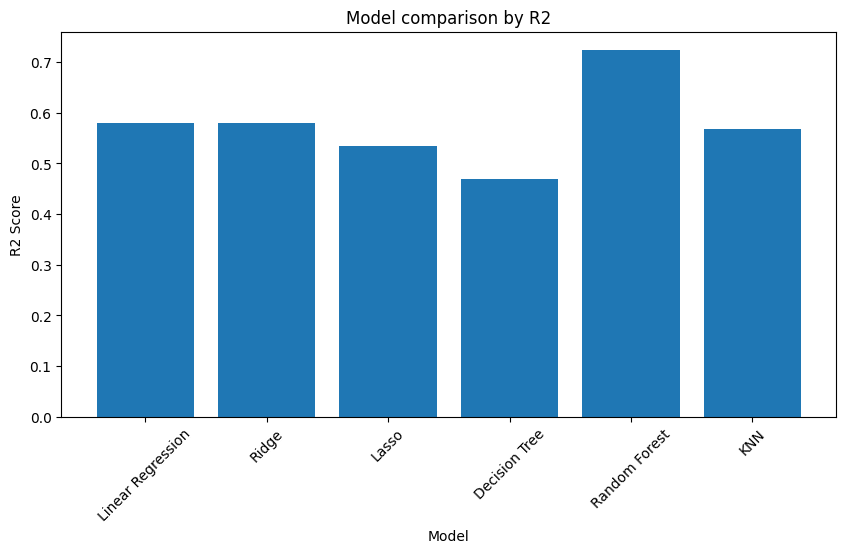

In [7]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model"], results_df["R2"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model comparison by R2")
plt.xticks(rotation=45)

plt.show()

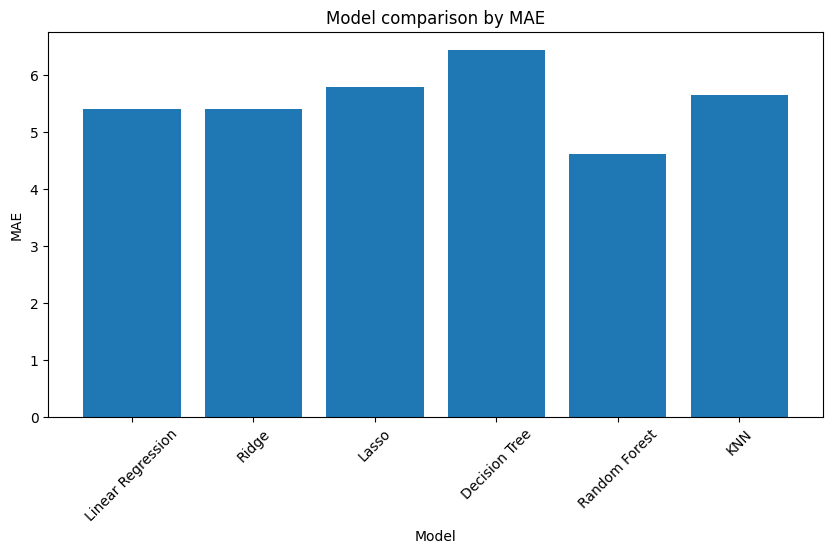

In [8]:
plt.figure(figsize=(10, 5))

plt.bar(results_df["Model"], results_df["MAE"])
plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model comparison by MAE")
plt.xticks(rotation=45)

plt.show()

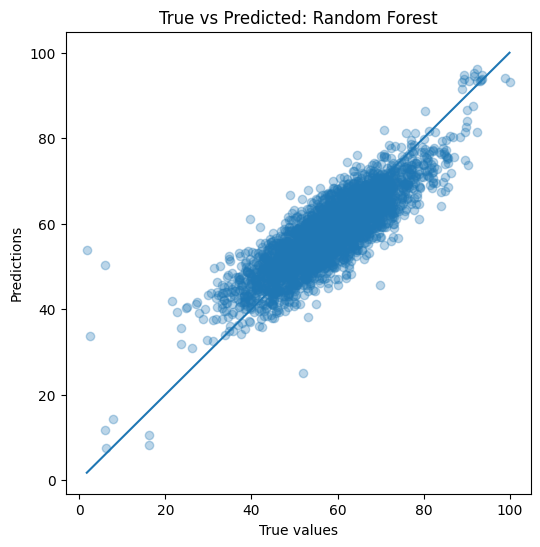

In [9]:
best_model_name = results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
best_pred = predictions[best_model_name]

plt.figure(figsize=(6, 6))

plt.scatter(y_test, best_pred, alpha=0.3)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.title(f"True vs Predicted: {best_model_name}")

min_value = min(y_test.min(), best_pred.min())
max_value = max(y_test.max(), best_pred.max())

plt.plot([min_value, max_value], [min_value, max_value])

plt.show()

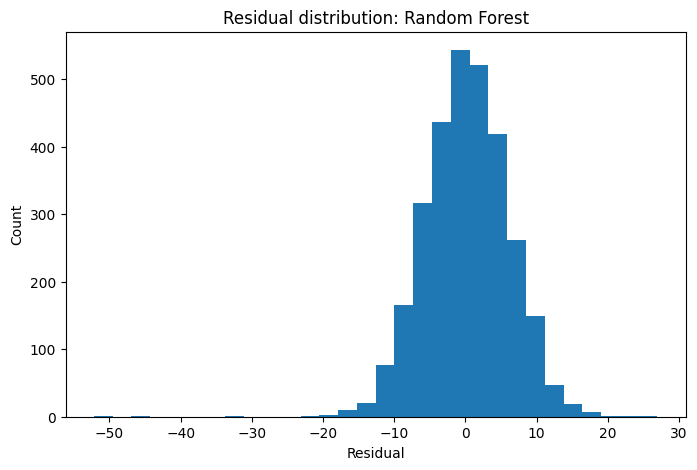

In [10]:
residuals = y_test - best_pred

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title(f"Residual distribution: {best_model_name}")

plt.show()

In [11]:
print("Best model:", best_model_name)
display(results_df.sort_values("R2", ascending=False))

Best model: Random Forest


,Model,MAE,MSE,R2
4,Random Forest,4.610477,34.745361,0.723731
1,Ridge,5.400418,52.846424,0.579805
0,Linear Regression,5.400487,52.848739,0.579787
5,KNN,5.638953,54.411215,0.567363
2,Lasso,5.781309,58.530706,0.534608
3,Decision Tree,6.431867,66.773640,0.469067
